In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_true = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=[1.0, 1.2, 0.8, 1.4],
    random_state=42
)

X = StandardScaler().fit_transform(X)
print("Shape:", X.shape)

Shape: (600, 2)


In [3]:
def plot_clusters(X, labels, medoid_points=None, title="Clusters"):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=18, alpha=0.85)
    if medoid_points is not None:
        plt.scatter(
            medoid_points[:, 0], medoid_points[:, 1],
            s=240, marker="X", edgecolor="black"
        )
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

## PAM

In [4]:
# Precalcular distancias euclidianas
def pairwise_euclidean_distances(X):
    G = np.sum(X * X, axis=1)
    D2 = G[:, None] + G[None, :] - 2.0 * (X @ X.T)
    D2 = np.maximum(D2, 0.0)
    return np.sqrt(D2)

In [5]:
# Asignación de medoides
def assign_to_medoids(D, medoid_indices):
    M = np.array(medoid_indices, dtype=int)
    dist_to_medoids = D[:, M]              # (n,K)
    nearest_pos = np.argmin(dist_to_medoids, axis=1)
    d1 = dist_to_medoids[np.arange(D.shape[0]), nearest_pos]
    return nearest_pos, d1, M

def total_cost_from_d1(d1):
    return float(np.sum(d1))

In [6]:
def pam_build(D, k):
    """
    BUILD: selección greedy de medoides.
    Retorna lista de indices de medoides.
    """
    n = D.shape[0]
    medoids = []

    # Primer medoid: minimiza suma de distancias a todos
    first = int(np.argmin(np.sum(D, axis=1)))
    medoids.append(first)

    # distancias al medoid
    d_nearest = D[:, first].copy()

    # Añadir medoids greedily
    for _ in range(1, k):
        improvements = np.zeros(n)
        for h in range(n):
            if h in medoids:
                improvements[h] = -np.inf
                continue
            improvements[h] = np.sum(np.maximum(0.0, d_nearest - D[:, h]))

        new_medoid = int(np.argmax(improvements))
        medoids.append(new_medoid)

        d_nearest = np.minimum(d_nearest, D[:, new_medoid])

    return medoids


# SWAP
def pam_swap(D, medoids, max_iter=100):
    n = D.shape[0]
    medoids = list(medoids)

    for _ in range(max_iter):
        M = np.array(medoids, dtype=int)

        # distancias a medoids: (n,K)
        dist_to_M = D[:, M]
        nearest_pos = np.argmin(dist_to_M, axis=1)
        d1 = dist_to_M[np.arange(n), nearest_pos]

        # second nearest distance
        dist_sorted = np.sort(dist_to_M, axis=1)
        d2 = dist_sorted[:, 1] if dist_to_M.shape[1] > 1 else np.full(n, np.inf)

        current_cost = np.sum(d1)

        best_delta = 0.0
        best_swap = None  # (pos_in_M, h_index)

        medoid_set = set(medoids)

        for pos_m, m_idx in enumerate(medoids):
            for h in range(n):
                if h in medoid_set:
                    continue
                # swap
                base = np.where(nearest_pos == pos_m, d2, d1)
                new_d = np.minimum(base, D[:, h])
                delta = np.sum(new_d) - current_cost

                if delta < best_delta:
                    best_delta = float(delta)
                    best_swap = (pos_m, h)

        if best_swap is None:
            break

        pos_m, h = best_swap
        medoid_set.remove(medoids[pos_m])
        medoids[pos_m] = h
        medoid_set.add(h)

    return medoids


# PAM: BUILD + SWAP
def PAM(D, k, max_iter=100):
    medoids0 = pam_build(D, k)
    medoids = pam_swap(D, medoids0, max_iter=max_iter)
    labels, d1, M = assign_to_medoids(D, medoids)
    cost = total_cost_from_d1(d1)
    return medoids, labels, cost

PAM
  Medoids: [181, 128, 365, 105]
  Cost: 142.4283


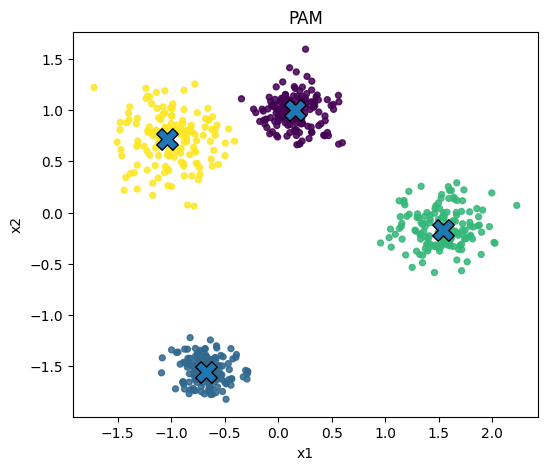

In [7]:
D = pairwise_euclidean_distances(X)

k = 4
medoids_pam, labels_pam, cost_pam = PAM(D, k=k, max_iter=50)

print("PAM")
print("  Medoids:", medoids_pam)
print("  Cost:", round(cost_pam, 4))

plot_clusters(X, labels_pam, X[np.array(medoids_pam)], title="PAM")

## CLARA

In [8]:
def CLARA(D, k, sample_size=None, num_samples=10, pam_max_iter=50, random_state=42):
    rng = np.random.default_rng(random_state)
    n = D.shape[0]

    if sample_size is None:
        sample_size = min(n, 40 + 2 * k)

    best_medoids = None
    best_cost = np.inf
    best_labels = None

    all_indices = np.arange(n)

    for _ in range(num_samples):
        S = rng.choice(all_indices, size=sample_size, replace=False)
        S_sorted = np.sort(S)

        # Submatriz de distancias
        D_S = D[np.ix_(S_sorted, S_sorted)]

        # PAM sobre submuestra
        medoids_S, _, _ = PAM(D_S, k=k, max_iter=pam_max_iter)

        # Convertir medoides a índices globales
        medoids_global = [int(S_sorted[m]) for m in medoids_S]

        # Evaluar sobre dataset completo
        labels_full, d1_full, _ = assign_to_medoids(D, medoids_global)
        cost_full = total_cost_from_d1(d1_full)

        if cost_full < best_cost:
            best_cost = cost_full
            best_medoids = medoids_global
            best_labels = labels_full

    return best_medoids, best_labels, float(best_cost)

CLARA
  Medoids: [181, 128, 542, 127]
  Cost: 142.9868


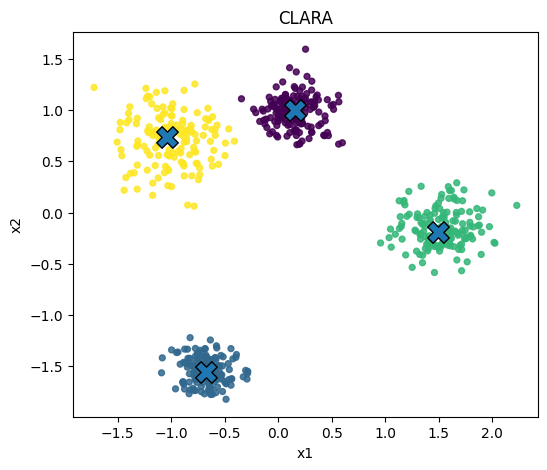

In [9]:
medoids_clara, labels_clara, cost_clara = CLARA(
    D, k=4, sample_size=120, num_samples=12, pam_max_iter=40, random_state=7
)

print("CLARA")
print("  Medoids:", medoids_clara)
print("  Cost:", round(cost_clara, 4))

plot_clusters(X, labels_clara, X[np.array(medoids_clara)], title="CLARA")

## Comparación

Cost comparison
  PAM   : 142.4283
  CLARA : 142.9868


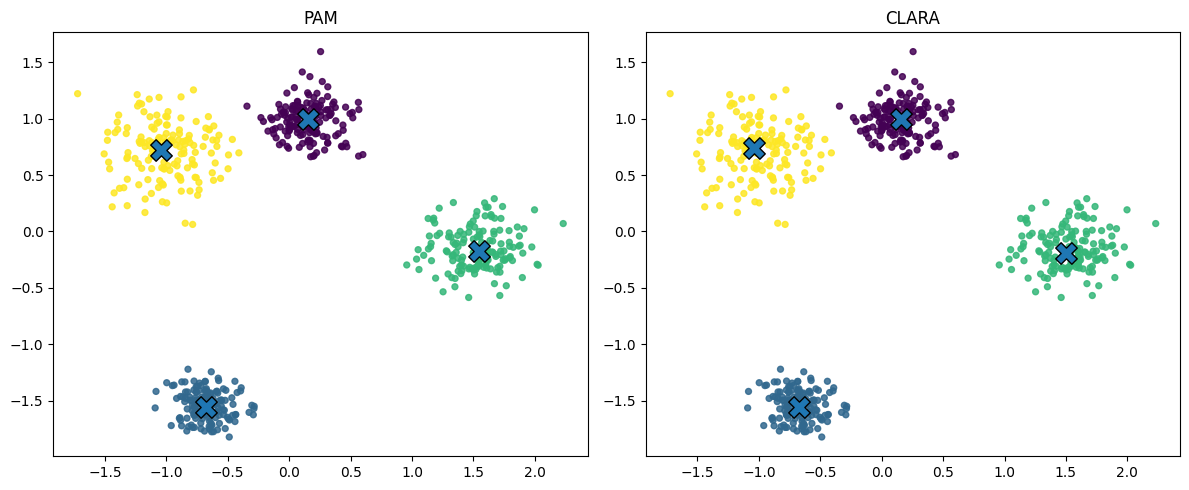

In [10]:
print("Cost comparison")
print("  PAM   :", round(cost_pam, 4))
print("  CLARA :", round(cost_clara, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=labels_pam, s=18, alpha=0.85)
axes[0].scatter(X[np.array(medoids_pam), 0], X[np.array(medoids_pam), 1], s=240, marker="X", edgecolor="black")
axes[0].set_title("PAM")

axes[1].scatter(X[:, 0], X[:, 1], c=labels_clara, s=18, alpha=0.85)
axes[1].scatter(X[np.array(medoids_clara), 0], X[np.array(medoids_clara), 1], s=240, marker="X", edgecolor="black")
axes[1].set_title("CLARA")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

X, y = load_wine(return_X_y=True)
X = StandardScaler().fit_transform(X)

In [26]:
D = pairwise_euclidean_distances(X)

k = 178
medoids_pam, labels_pam, cost_pam = PAM(D, k=k, max_iter=200)

print("PAM")
print("  Medoids:", medoids_pam)
print("  Cost:", round(cost_pam, 4))

PAM
  Medoids: [37, 148, 106, 56, 88, 163, 120, 53, 97, 78, 162, 35, 61, 150, 12, 25, 43, 158, 165, 131, 5, 125, 86, 79, 59, 110, 107, 73, 96, 121, 135, 63, 38, 175, 47, 19, 71, 13, 124, 48, 95, 115, 127, 118, 136, 77, 123, 112, 99, 69, 166, 84, 60, 74, 50, 70, 82, 75, 72, 155, 31, 66, 157, 122, 129, 29, 169, 62, 85, 4, 104, 103, 177, 105, 167, 58, 146, 137, 45, 14, 94, 153, 130, 152, 46, 83, 65, 119, 68, 144, 64, 76, 21, 100, 93, 143, 141, 30, 113, 33, 117, 128, 2, 154, 28, 32, 149, 36, 1, 109, 164, 176, 39, 147, 26, 90, 41, 7, 108, 159, 140, 8, 55, 101, 3, 134, 16, 42, 49, 114, 151, 168, 23, 126, 161, 89, 81, 102, 80, 0, 52, 171, 51, 173, 18, 160, 145, 138, 67, 10, 132, 44, 156, 139, 54, 87, 91, 174, 6, 170, 111, 57, 98, 142, 27, 24, 116, 40, 22, 172, 17, 20, 34, 92, 15, 11, 133, 9]
  Cost: 0.0
